In [3]:
import os
import json
import matplotlib.pyplot as plt
import numpy as np
import glob

## Enduro

fire 유지

fire 제외

## Pong

## Space Invaders

In [4]:
def collect_npz_files(base_dir, sub_num, game_num):
    # 예: base_dir = 'behavioral_data_4kframe_legacy'
    target_dir = os.path.join(base_dir, f"sub_{sub_num}", f"game_{game_num}")
    npz_files = []
    # day_*, block_* 하위의 모든 npz 파일 찾기
    for day in os.listdir(target_dir):
        day_path = os.path.join(target_dir, day)
        if os.path.isdir(day_path) and day.startswith("day_"):
            for block in os.listdir(day_path):
                block_path = os.path.join(day_path, block)
                if os.path.isdir(block_path) and block.startswith("block_"):
                    npz_files.extend(glob.glob(os.path.join(block_path, "*.npz")))
    return npz_files

# 사용 예시
base_dir = "behavioral_data_block"
sub_num = 1
game_num = 2
npz_list = collect_npz_files(base_dir, sub_num, game_num)
all_data = []
for npz_path in npz_list:
    data = np.load(npz_path)
    all_data.append({key: data[key] for key in data.files})

FileNotFoundError: [Errno 2] No such file or directory: 'behavioral_data_block/sub_1/game_2'

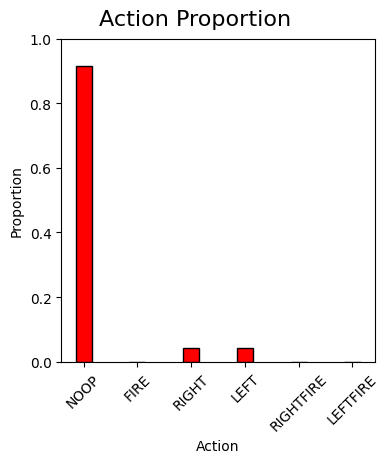

In [9]:
action_mapping = {
    'NOOP': 0,
    'FIRE': 1,
    'RIGHT': 2,
    'LEFT': 3,
    'RIGHTFIRE': 4,
    'LEFTFIRE': 5,
}
all_possible_actions = np.arange(len(action_mapping))  # [0, 1, 2, 3, 4, 5]

def plot_action_distribution(npz_list, num_splits=5):
    # 1. Find the maximum length among all npz files
    max_length = 0
    all_actions = []
    for npz_path in npz_list:
        data = np.load(npz_path)
        actions = data['action']  # shape: (T, num_actions)
        all_actions.append(actions)
        if len(actions) > max_length:
            max_length = len(actions)

    # 2. Define global split indices based on the maximum length
    split_indices = np.linspace(0, max_length, num_splits+1, dtype=int)

    # 3. For each segment, gather all actions from all files, then compute proportion
    segment_ratios = []
    for i in range(num_splits):
        start, end = split_indices[i], split_indices[i+1]
        segment_actions = []
        for actions in all_actions:
            if len(actions) > start:
                seg = actions[start:min(end, len(actions))]
                if len(seg) > 0:
                    segment_actions.append(seg)
        if segment_actions:
            segment_actions = np.concatenate(segment_actions, axis=0)  # shape: (total_steps, num_actions)
            action_counts = segment_actions.sum(axis=0)
            if action_counts.sum() > 0:
                ratio = action_counts / action_counts.sum()
            else:
                ratio = np.zeros(len(action_mapping))
        else:
            ratio = np.zeros(len(action_mapping))
        segment_ratios.append(ratio)

    segment_ratios = np.array(segment_ratios)  # (num_splits, num_actions)

    # Plot: segment별 subplot
    plt.figure(figsize=(4 * num_splits, 4.5))
    for i in range(num_splits):
        plt.subplot(1, num_splits, i+1)
        plt.bar(
            all_possible_actions,
            segment_ratios[i],
            color='red',
            width=0.3,
            edgecolor='black'
        )
        #plt.title(f"Segment {i+1}")
        plt.xlabel("Action")
        plt.ylabel("Proportion")
        plt.ylim(0, 1)
        plt.xticks(all_possible_actions, list(action_mapping.keys()), rotation=45)
    plt.tight_layout()
    plt.suptitle("Action Proportion", y=1.02, fontsize=16)
    plt.show()
plot_action_distribution(npz_list, num_splits=1)

# Thinker

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 행동 ID 매핑 (이름은 그대로 유지)
action_mapping = {
    'NOOP': 0,
    'FIRE': 1,
    'RIGHT': 2,
    'LEFT': 3,
    'RIGHTFIRE': 4,
    'LEFTFIRE': 5,
}
all_possible_actions = np.arange(len(action_mapping))  # [0, 1, 2, 3, 4, 5]

def plot_root_action_distribution(npy_list, num_splits=5):
    # 1. 모든 npy 파일에서 status, root_action 불러오기
    max_length = 0
    all_status = []
    all_root_action = []

    for npy_path in npy_list:
        data = np.load(npy_path, allow_pickle=True)

        # dict 형태로 저장된 경우 (np.save로 dict 저장 후 사용)
        if isinstance(data, np.ndarray) and data.dtype == object:
            data = data.item()

        if isinstance(data, dict):
            status = np.array(data['status'])
            root_action = np.array(data['tree_reps']['root_action'])
        else:
            # 구조화 배열(필드가 있는 ndarray) 형태인 경우
            status = data['status']
            root_action = data['tree_reps']['root_action']

        all_status.append(status)
        all_root_action.append(root_action)
        if len(status) > max_length:
            max_length = len(status)

    # 2. 최대 길이에 따라 전역 구간 분할 인덱스 정의
    split_indices = np.linspace(0, max_length, num_splits + 1, dtype=int)

    # 3. 각 구간별로 모든 파일에서 status==0인 root_action만 모아서 비율 계산
    segment_ratios = []
    for i in range(num_splits):
        start, end = split_indices[i], split_indices[i + 1]
        segment_root_actions = []

        for status, root_action in zip(all_status, all_root_action):
            if len(status) > start:
                seg_end = min(end, len(status))
                seg_status = np.array(status[start:seg_end])
                seg_root_action = np.array(root_action[start:seg_end])

                mask = (seg_status == 0)
                if np.any(mask):
                    segment_root_actions.append(seg_root_action[mask])

        if segment_root_actions:
            # (N, num_actions) 형태로 이어붙인 뒤, 각 액션 차원별로 합산
            segment_root_actions = np.concatenate(segment_root_actions, axis=0)
            segment_root_actions = np.asarray(segment_root_actions)

            if segment_root_actions.ndim == 1:
                # 만약 1D 정수 인덱스라면 히스토그램
                action_counts = np.bincount(
                    segment_root_actions.astype(int),
                    minlength=len(action_mapping)
                )
            else:
                # (N, num_actions) 분포/one-hot이면 액션 차원으로 합산
                action_counts = segment_root_actions.sum(axis=0)

            if action_counts.sum() > 0:
                ratio = action_counts / action_counts.sum()
            else:
                ratio = np.zeros(len(action_mapping))
        else:
            ratio = np.zeros(len(action_mapping))

        segment_ratios.append(ratio)

    segment_ratios = np.array(segment_ratios)  # (num_splits, num_actions)

    # 4. Plot: 구간별 subplot, 스타일은 기존과 동일
    plt.figure(figsize=(4 * num_splits, 4.5))
    for i in range(num_splits):
        plt.subplot(1, num_splits, i + 1)
        plt.bar(
            all_possible_actions,
            segment_ratios[i],
            color='blue',
            width=0.3,
            edgecolor='black'
        )
        plt.xlabel("Action")
        plt.ylabel("Proportion")
        plt.ylim(0, 1)
        plt.xticks(all_possible_actions, list(action_mapping.keys()), rotation=45)

    plt.tight_layout()
    plt.suptitle("Action Proportion", y=1.02, fontsize=16)
    plt.show()


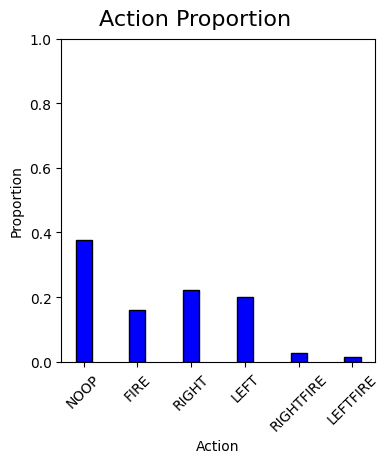

In [2]:
npy_list = [
            #'/home/jmme425/thinker/test/thinker-20251023-165530-327280-0/video_stat.npy'
            #'/home/jmme425/thinker/test/thinker-20251206-222804-1082768-0/video_stat.npy',
            #'/home/jmme425/thinker/test/thinker-20251206-222804-1082768-1/video_stat.npy',
            #'/home/jmme425/thinker/test/thinker-20251206-222804-1082768-2/video_stat.npy'
            #'/home/jmme425/thinker/test/example/pong_45e5_0.npy',
            #'/home/jmme425/thinker/test/dd/spaceinvaders_10e6_1.npy',
            #'/home/jmme425/thinker/test/dd/spaceinvaders_10e6_2.npy'
            '/home/jmme425/thinker/test/sub001-ses01-block3-game2/video_stat_000.npy'
            ]
plot_root_action_distribution(npy_list, num_splits=1)